Utilizzando il dataset Iris, replicare l'esercitazione pratica
    - Effettuare la standarizzazione dei dati
    - Addestrare due modelli SVC
        - kernel=linear, C=1.0, random_state=42
        - kernel=rbf, C=1.0, random_state=42
    - Utilizzare le prime due feature (sepal_lenght e sepal_width) per creare una numpy.meshgrid e plottare i decision boundary (regioni di classificazione), differenziate per colore

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

Utilizzando il dataset Iris, replicare l'esercitazione pratica

In [3]:
data=load_iris()
X=data.data
y=data.target
display(pd.DataFrame(X, columns=data.feature_names).head())
display(pd.DataFrame(y, columns=["target"]).groupby("target").size())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


target
0    50
1    50
2    50
dtype: int64

    - Effettuare la standarizzazione dei dati

In [4]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

    - Addestrare due modelli SVC
        - kernel=linear, C=1.0, random_state=42
        - kernel=rbf, C=1.0, random_state=42

In [5]:
svc_linear=SVC(kernel="linear",C=1.0,random_state=42)
svc_linear.fit(X_scaled,y)
y_pred_linear=svc_linear.predict(X_scaled)
mse_linear=mean_squared_error(y,y_pred_linear)
r2_linear=r2_score(y,y_pred_linear)

In [6]:
svc_rbf=SVC(kernel="rbf",C=1.0,random_state=42)
svc_rbf.fit(X_scaled,y)
y_pred=svc_rbf.predict(X_scaled)
mse_rbf=mean_squared_error(y,y_pred)
r2_rbf=r2_score(y,y_pred)

In [7]:
print(f"LINEAR \nMSE: {mse_linear}\t R2:{r2_linear}")
print(f"RBF \nMSE: {mse_rbf}\t R2:{r2_rbf}")

LINEAR 
MSE: 0.03333333333333333	 R2:0.95
RBF 
MSE: 0.02666666666666667	 R2:0.96


    - Utilizzare le prime due feature (sepal_lenght e sepal_width) per creare una numpy.meshgrid e plottare i decision boundary (regioni di classificazione), differenziate per colore

In [8]:
feature_0=0
feature_1=1
X_2d=X_scaled[:,[feature_0,feature_1]]

In [10]:
svc_linear_plot=SVC(kernel="linear",C=1.0,random_state=42)
svc_linear_plot.fit(X_2d,y)
svc_rbf_plot=SVC(kernel="rbf",C=1.0,random_state=42)
svc_rbf_plot.fit(X_2d,y)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [11]:
X_min, X_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
Y_min, Y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(X_min, X_max, 0.02), np.arange(Y_min, Y_max, 0.01))

In [12]:
Z_linear = svc_linear_plot.predict(np.c_[xx.ravel(), yy.ravel()])
Z_linear = Z_linear.reshape(xx.shape)
Z_rbf = svc_rbf_plot.predict(np.c_[xx.ravel(), yy.ravel()])
Z_rbf = Z_rbf.reshape(xx.shape)

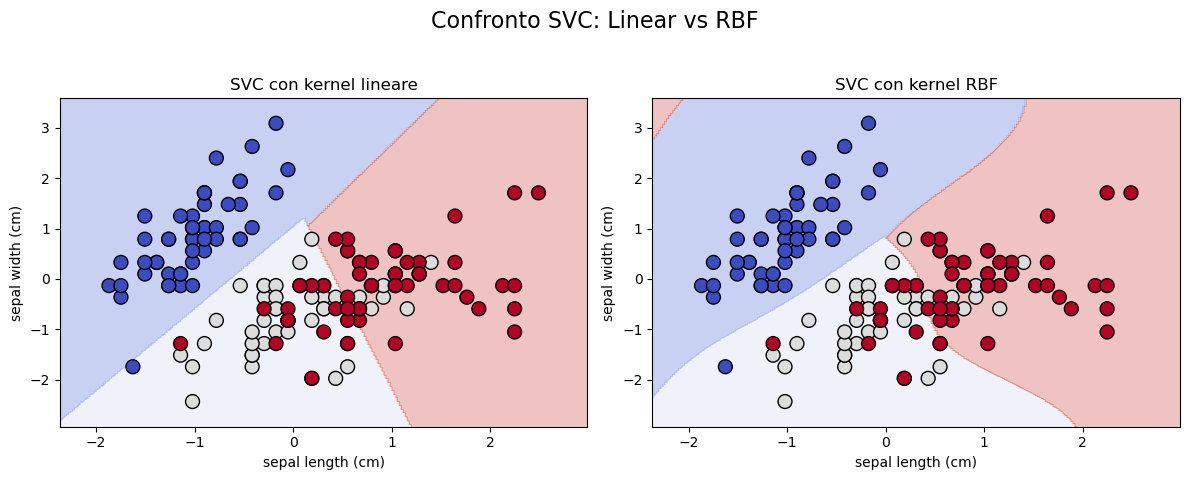

In [13]:
plt.figure(figsize=(12, 5))
plt.suptitle("Confronto SVC: Linear vs RBF", fontsize=16)

plt.subplot(1, 2, 1)
plt.contourf(xx, yy, Z_linear, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, edgecolors='k', marker='o', s=100, cmap=plt.cm.coolwarm)
plt.title("SVC con kernel lineare") 
plt.xlabel(data.feature_names[feature_0])
plt.ylabel(data.feature_names[feature_1])
plt.subplot(1, 2, 2)
plt.contourf(xx, yy, Z_rbf, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, edgecolors='k', marker='o', s=100, cmap=plt.cm.coolwarm)
plt.title("SVC con kernel RBF")
plt.xlabel(data.feature_names[feature_0])
plt.ylabel(data.feature_names[feature_1])
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Non ho grossi miglioramenti utilizzando il kernel rbf, pertanto non è giustificato l'utilizzo di un modello complesso rispetto al più semplice lineare